## Vykreslenie grafov pre modely na predikciu DST+6

Súbor: graf_DST+6.ipynb

Program: Hospodárska informatika

Vypracovala: Bc. Terézia Drengubiaková

Bakalárska práca: : Metódy strojového učenia pre včasnú predikciu geomagnetických búrok

Vedúci diplomovej práce: doc. Ing. Peter Butka, PhD.

Konzultanti: Ing. Viera Krešňáková, PhD., RNDr. Šimon Mackovjak, PhD.

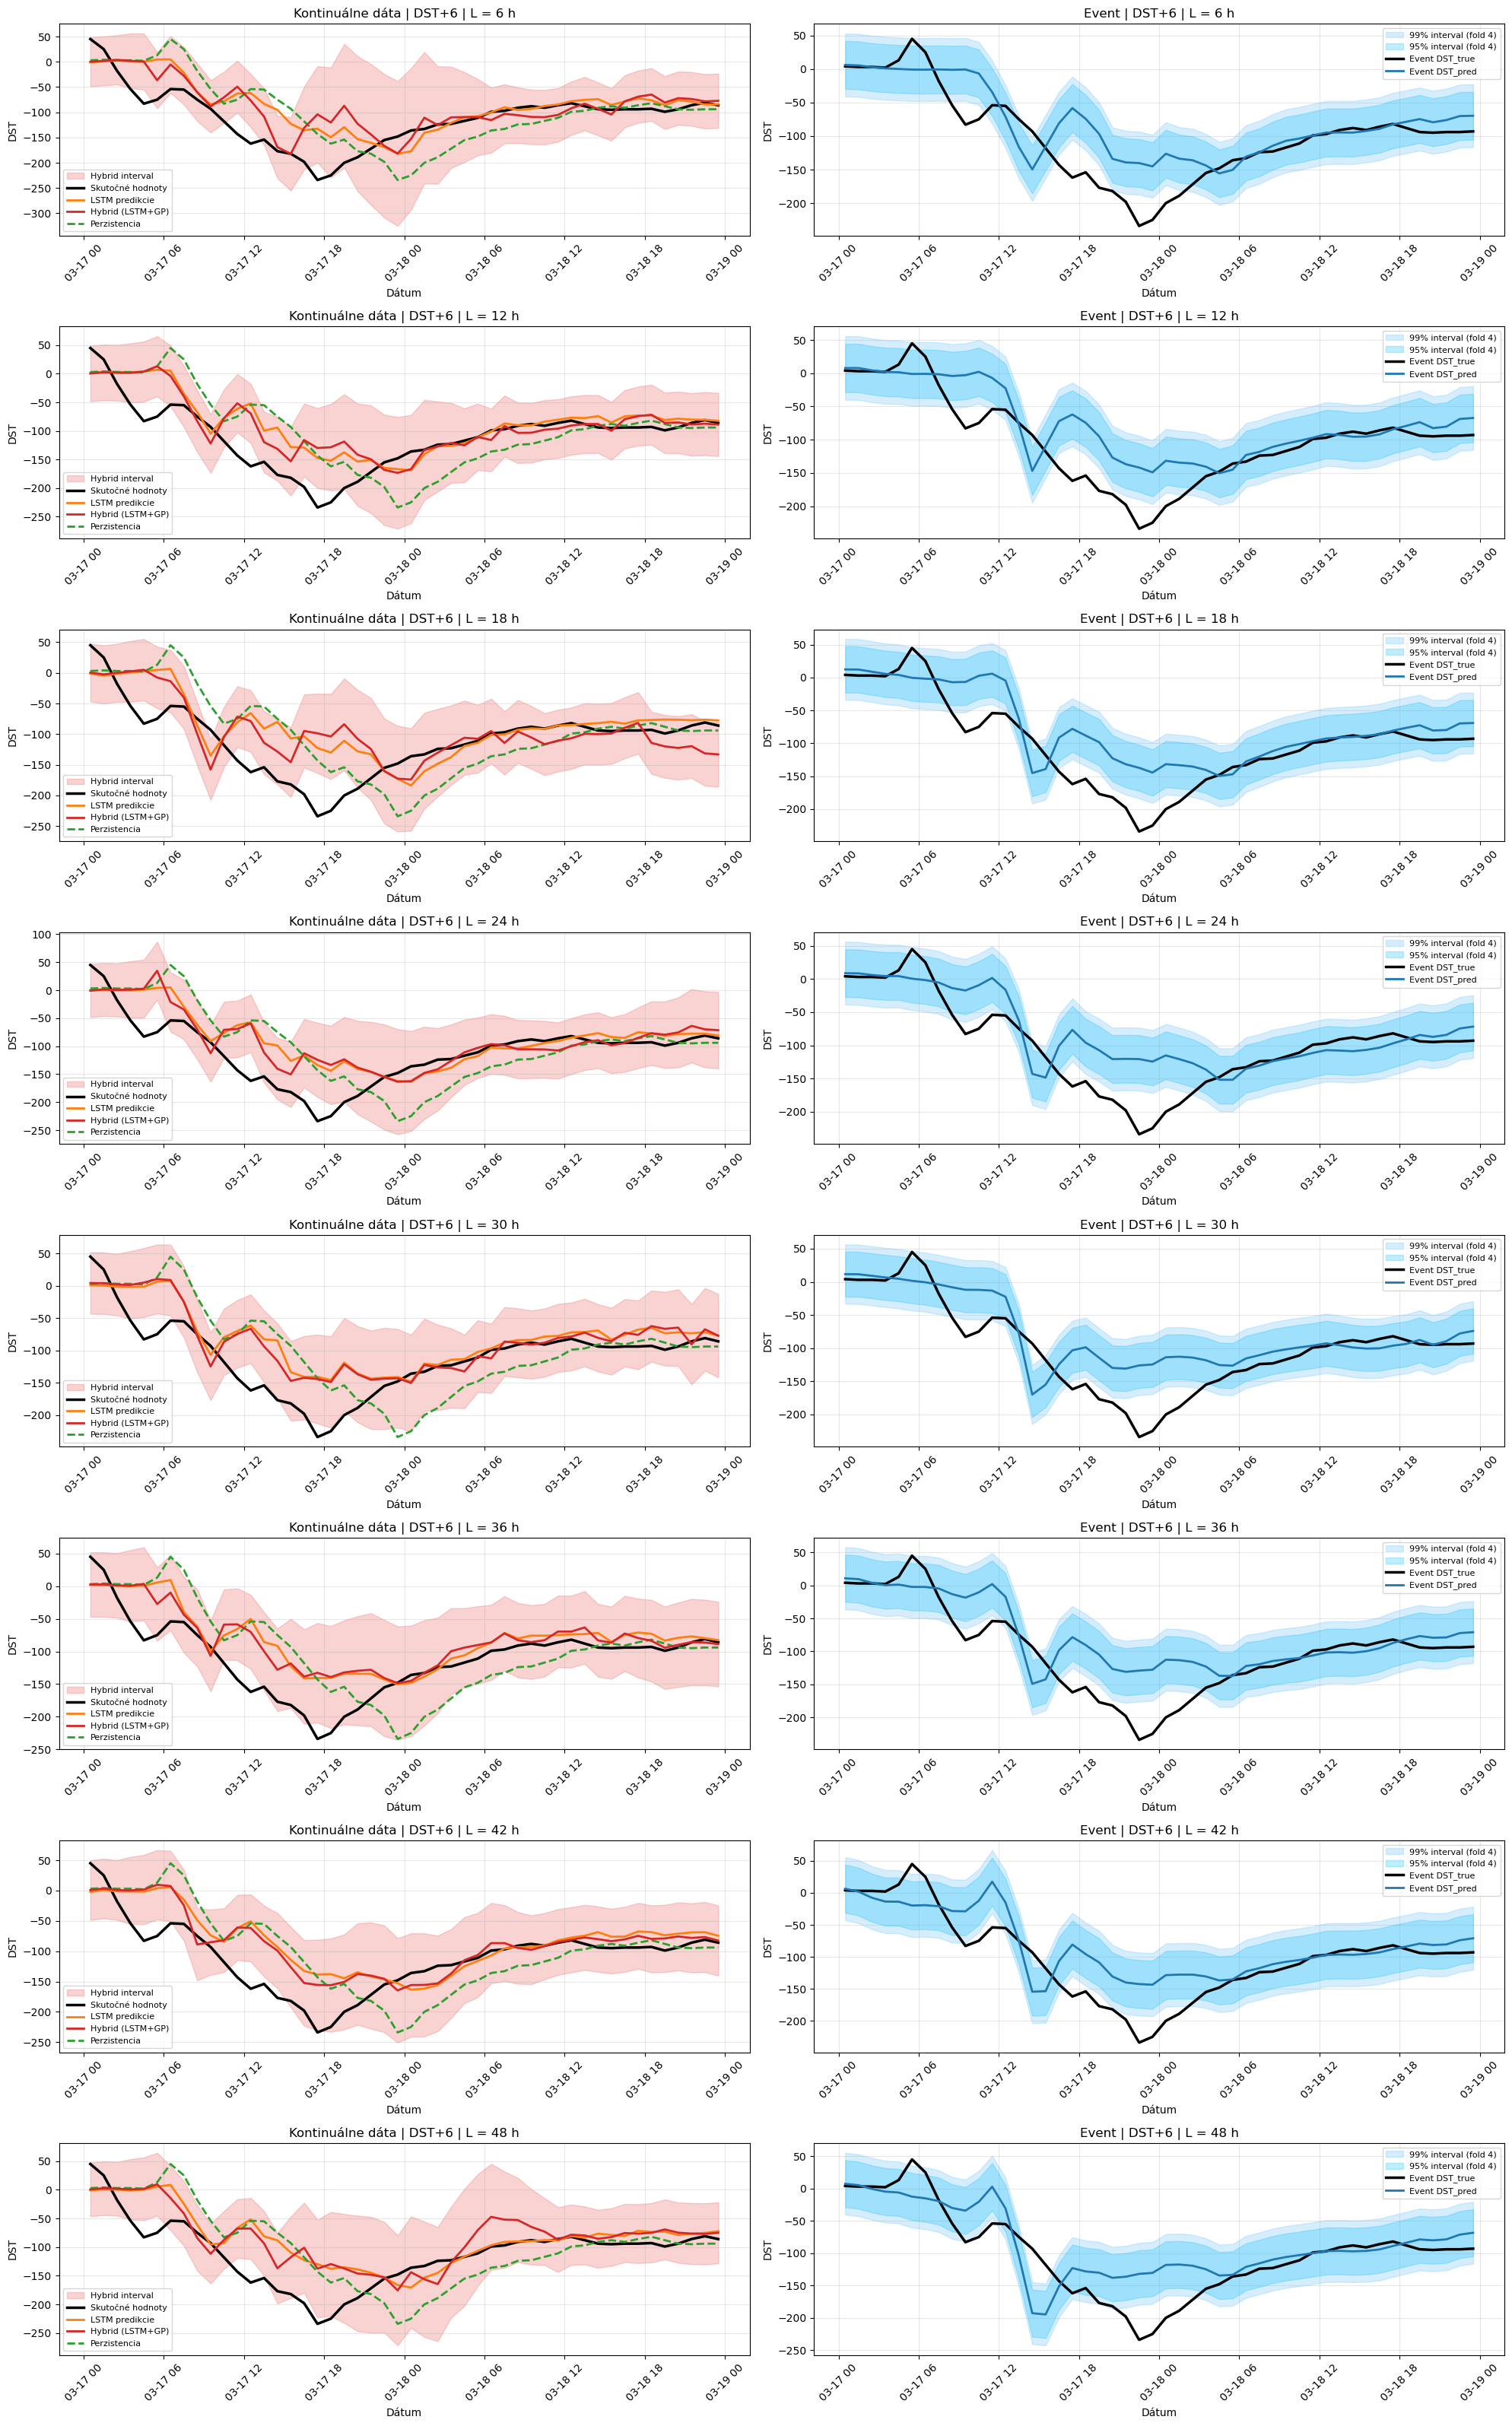

,L_idx,L_hours,found_fold,filename,n_rows_in_range
0,1,6,4,event_fold4_L1_H6.csv,48
1,2,12,4,event_fold4_L2_H6.csv,48
2,3,18,4,event_fold4_L3_H6.csv,48
3,4,24,4,event_fold4_L4_H6.csv,48
4,5,30,4,event_fold4_L5_H6.csv,48
5,6,36,4,event_fold4_L6_H6.csv,48
6,7,42,4,event_fold4_L7_H6.csv,48
7,8,48,4,event_fold4_L8_H6.csv,48


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Nastavenia
# =========================================================
start_date = '2015-03-17'
end_date = '2015-03-19'

base_dir_original = "."
events_dir = "events"

L_VALUES = [6, 12, 18, 24, 30, 36, 42, 48]
H_VALUE = 6
FOLDS = [1, 2, 3, 4, 5]

Z95 = 1.96
Z99 = 2.576

# =========================================================
# Načítanie pôvodných dát
# =========================================================
def load_original_dataframes(extension):
    dataframes = []
    for i in range(6, 49, 6):
        filename = os.path.join(
            base_dir_original,
            f'V+BZ_GSM/prediction_comparison_DST+6{extension}{i}H.csv'
        )
        df = pd.read_csv(filename, parse_dates=['time'])
        df = df[(df['time'] >= start_date) & (df['time'] <= end_date)].copy()
        dataframes.append(df)
    return dataframes

# =========================================================
# Nájde event CSV pre dané L_idx a H
# =========================================================
def find_event_df_for_range(events_dir, L_idx, H=6, folds=(1, 2, 3, 4, 5),
                            start_date='2015-03-17', end_date='2004-11-10'):
    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)

    candidates = []

    for fold in folds:
        path = os.path.join(events_dir, f'event_fold{fold}_L{L_idx}_H{H}.csv')
        if not os.path.exists(path):
            continue

        try:
            df = pd.read_csv(path)

            time_col = None
            for c in ["time", "Time", "datetime", "date", "Date", "timestamp"]:
                if c in df.columns:
                    time_col = c
                    break

            if time_col is None:
                continue

            df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
            df = df[(df[time_col] >= start_ts) & (df[time_col] <= end_ts)].copy()

            if len(df) > 0:
                candidates.append((fold, path, time_col, df))

        except Exception as e:
            print(f"Chyba pri čítaní {path}: {e}")

    if not candidates:
        return None, None, None, None

    candidates = sorted(candidates, key=lambda x: len(x[3]), reverse=True)
    return candidates[0]

# =========================================================
# Pomocné funkcie
# =========================================================
def ensure_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def add_missing_event_intervals(df):
    df = df.copy()

    # 95 %
    if {"DST_p025", "DST_p975"}.issubset(df.columns):
        df = ensure_numeric(df, ["DST_p025", "DST_p975"])
    elif {"DST_pred", "sigma_nT"}.issubset(df.columns):
        df = ensure_numeric(df, ["DST_pred", "sigma_nT"])
        df["DST_p025"] = df["DST_pred"] - Z95 * df["sigma_nT"]
        df["DST_p975"] = df["DST_pred"] + Z95 * df["sigma_nT"]

    # 99 %
    if {"DST_p005", "DST_p995"}.issubset(df.columns):
        df = ensure_numeric(df, ["DST_p005", "DST_p995"])
    elif {"DST_pred", "sigma_nT"}.issubset(df.columns):
        df = ensure_numeric(df, ["DST_pred", "sigma_nT"])
        df["DST_p005"] = df["DST_pred"] - Z99 * df["sigma_nT"]
        df["DST_p995"] = df["DST_pred"] + Z99 * df["sigma_nT"]

    return df

def plot_interval(ax, x, lower, upper, label, color=None, alpha=0.3, zorder=1):
    x = pd.to_datetime(x, errors="coerce")
    lower = pd.to_numeric(lower, errors="coerce")
    upper = pd.to_numeric(upper, errors="coerce")

    mask = x.notna() & lower.notna() & upper.notna()
    if mask.sum() == 0:
        print(f"[WARN] Interval '{label}' sa nevykreslil - všetko je NaN alebo chýba.")
        return

    ax.fill_between(
        x[mask],
        lower[mask],
        upper[mask],
        label=label,
        alpha=alpha,
        color=color,
        zorder=zorder
    )

    width = (upper[mask] - lower[mask]).mean()

# =========================================================
# Načítaj pôvodné dáta
# =========================================================
dataframes = load_original_dataframes('_LSTM_')

# =========================================================
# Plot
# =========================================================
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(20, 32))
found_folds_summary = []

for i in range(8):
    L_idx = i + 1
    L_hours = L_VALUES[i]

    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    # -----------------------------------------------------
    # LEFT: pôvodná metóda
    # -----------------------------------------------------
    df_orig = dataframes[i].copy()

    if len(df_orig) > 0:
        df_orig = df_orig.sort_values("time").copy()
        df_orig["time"] = pd.to_datetime(df_orig["time"], errors="coerce")

        numeric_cols = [
            "y_true", "y_lstm", "y_hybrid",
            "hybrid_lower", "hybrid_upper", "y_pred_persistence"
        ]
        df_orig = ensure_numeric(df_orig, numeric_cols)

        if {"hybrid_lower", "hybrid_upper"}.issubset(df_orig.columns):
            plot_interval(
                ax_left,
                df_orig["time"],
                df_orig["hybrid_lower"],
                df_orig["hybrid_upper"],
                label="Hybrid interval",
                color="lightcoral",
                alpha=0.35,
                zorder=1
            )

        if "y_true" in df_orig.columns:
            ax_left.plot(
                df_orig["time"],
                df_orig["y_true"],
                label="Skutočné hodnoty",
                linewidth=2.5,
                color="black",
                zorder=3
            )

        if "y_lstm" in df_orig.columns:
            ax_left.plot(
                df_orig["time"],
                df_orig["y_lstm"],
                label="LSTM predikcie",
                linewidth=2,
                color="tab:orange",
                zorder=4
            )

        if "y_hybrid" in df_orig.columns:
            ax_left.plot(
                df_orig["time"],
                df_orig["y_hybrid"],
                label="Hybrid (LSTM+GP)",
                linewidth=2,
                color="tab:red",
                zorder=5
            )
        if "y_pred_persistence" in df_orig.columns:
            ax_left.plot(
                df_orig["time"],
                df_orig["y_pred_persistence"],
                label="Perzistencia",
                linewidth=2,
                linestyle="--",
                color="tab:green",
                zorder=4
            )

    ax_left.set_title(f'Kontinuálne dáta | DST+6 | L = {L_hours} h')
    ax_left.set_xlabel('Dátum')
    ax_left.set_ylabel('DST')
    ax_left.legend(fontsize=8)
    ax_left.tick_params(axis='x', rotation=45)
    ax_left.grid(alpha=0.3)

    # -----------------------------------------------------
    # RIGHT: event CSV
    # -----------------------------------------------------
    result = find_event_df_for_range(
        events_dir=events_dir,
        L_idx=L_idx,
        H=H_VALUE,
        folds=FOLDS,
        start_date=start_date,
        end_date=end_date
    )

    if result[0] is not None:
        fold, path, time_col, df_evt = result
        found_folds_summary.append((L_idx, L_hours, fold, os.path.basename(path), len(df_evt)))

        df_evt = df_evt.sort_values(time_col).copy()
        df_evt[time_col] = pd.to_datetime(df_evt[time_col], errors="coerce")
        df_evt = add_missing_event_intervals(df_evt)
        df_evt = ensure_numeric(df_evt, ["DST_true", "DST_pred", "DST_p025", "DST_p975", "DST_p005", "DST_p995"])

        if {"DST_p005", "DST_p995"}.issubset(df_evt.columns):
            plot_interval(
                ax_right,
                df_evt[time_col],
                df_evt["DST_p005"],
                df_evt["DST_p995"],
                label=f"99% interval (fold {fold})",
                color="lightskyblue",
                alpha=0.35,
                zorder=1
            )

        if {"DST_p025", "DST_p975"}.issubset(df_evt.columns):
            plot_interval(
                ax_right,
                df_evt[time_col],
                df_evt["DST_p025"],
                df_evt["DST_p975"],
                label=f"95% interval (fold {fold})",
                color="deepskyblue",
                alpha=0.25,
                zorder=2
            )

        if "DST_true" in df_evt.columns:
            ax_right.plot(
                df_evt[time_col],
                df_evt["DST_true"],
                label="Event DST_true",
                linewidth=2.5,
                color="black",
                zorder=4
            )

        if "DST_pred" in df_evt.columns:
            ax_right.plot(
                df_evt[time_col],
                df_evt["DST_pred"],
                label="Event DST_pred",
                linewidth=2,
                color="tab:blue",
                zorder=5
            )

        ax_right.set_title(f'Event | DST+6 | L = {L_hours} h')

    else:
        found_folds_summary.append((L_idx, L_hours, None, None, 0))
        ax_right.set_title(f'Event | DST+6 | L = {L_hours} h | nenašiel sa fold')
        ax_right.text(
            0.5, 0.5,
            'Pre tento interval sa nenašli dáta',
            ha='center',
            va='center',
            transform=ax_right.transAxes,
            fontsize=11
        )

    ax_right.set_xlabel('Dátum')
    ax_right.set_ylabel('DST')
    ax_right.legend(fontsize=8)
    ax_right.tick_params(axis='x', rotation=45)
    ax_right.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("rozne_dlzky_okna_DST+6_16_grafov_intervaly_oboje.jpg", dpi=200, bbox_inches="tight")
plt.show()

summary_df = pd.DataFrame(
    found_folds_summary,
    columns=["L_idx", "L_hours", "found_fold", "filename", "n_rows_in_range"]
)
display(summary_df)